# Evaluate Model Performance



## Regional Model Preparation

In [4]:
from pathlib import Path
import argparse

import torch
from neuralhydrology.nh_run import start_run

def main():
    # Define the command-line arguments
    parser = argparse.ArgumentParser(description='Run the model training with a specified config file.')
    parser.add_argument('--config', type=str, required=True, help='Path to the config file')

    # Parse the arguments
    args = parser.parse_args()

    # Use the provided config file path
    config_file_path = Path(args.config)

    # Start the run with the specified config file
    start_run(config_file=config_file_path)

if __name__ == "__main__":
    # main()
    start_run(config_file=Path('config.yml'))

2025-05-04 21:32:00,001: Logging to c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159\output.log initialized.
2025-05-04 21:32:00,001: ### Folder structure created at c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,003: ### Run configurations for EA-LSTM_Regional
2025-05-04 21:32:00,003: experiment_name: EA-LSTM_Regional
2025-05-04 21:32:00,004: run_dir: c:\Users\ybrot\Desktop\course\UROP\GAGEii_modeling\runs\EA-LSTM_Regional_0405_213159
2025-05-04 21:32:00,004: train_basin_file: basin_list\regional_train.txt
2025-05-04 21:32:00,005: validation_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: test_basin_file: basin_list\regional_test.txt
2025-05-04 21:32:00,005: train_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,005: train_end_date: 2023-12-31 00:00:00
2025-05-04 21:32:00,006: validation_start_date: 2005-01-01 00:00:00
2025-05-04 21:32:00,006: validation_end_date: 2023-12

TypeError: '<' not supported between instances of 'str' and 'Timestamp'

## Import Evaluator Module

In [2]:
from util.Evaluator import Evaluator

## Load Model

In [7]:
model_dir = "EA-LSTM_Regional_0405_214651" # Specify the model name
epoch_num = 6 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/test.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=0.927313,
                      var=4.24383,
                      apply_transformation=True,)

100%|██████████| 195/195 [00:13<00:00, 14.81it/s]


In [8]:
print(evaluator)

Summary Statistic: 
count    168.000000
mean      -4.082910
std       17.589572
min     -137.200261
25%       -0.480849
50%        0.392170
75%        0.599147
max        0.817615
Name: NSE, dtype: float64

Summary Statistic: 
count    168.000000
mean      -0.261491
std        2.224029
min      -17.729494
25%       -0.098031
50%        0.349516
75%        0.593758
max        0.872013
Name: KGE, dtype: float64

Performance Summary: 
Performance
Good              80
Negative          54
N/A               27
Unsatisfactory    27
Excellent          7
Name: count, dtype: int64

evaluate EA-LSTM_Regional_0405_214651 epoch 6


In [21]:
print(evaluator)

Summary Statistic: 
count    167.000000
mean      -2.036469
std       12.100365
min     -119.593875
25%       -0.180925
50%        0.241054
75%        0.590312
max        0.836012
Name: NSE, dtype: float64

Summary Statistic: 
count    167.000000
mean       0.082973
std        1.141252
min       -8.984719
25%        0.042855
50%        0.310940
75%        0.611081
max        0.856197
Name: KGE, dtype: float64

Performance Summary: 
Performance
Good              68
Negative          60
Unsatisfactory    34
N/A               28
Excellent          5
Name: count, dtype: int64

evaluate EALSTM-RegionallySeparated_2403_112435 epoch 6


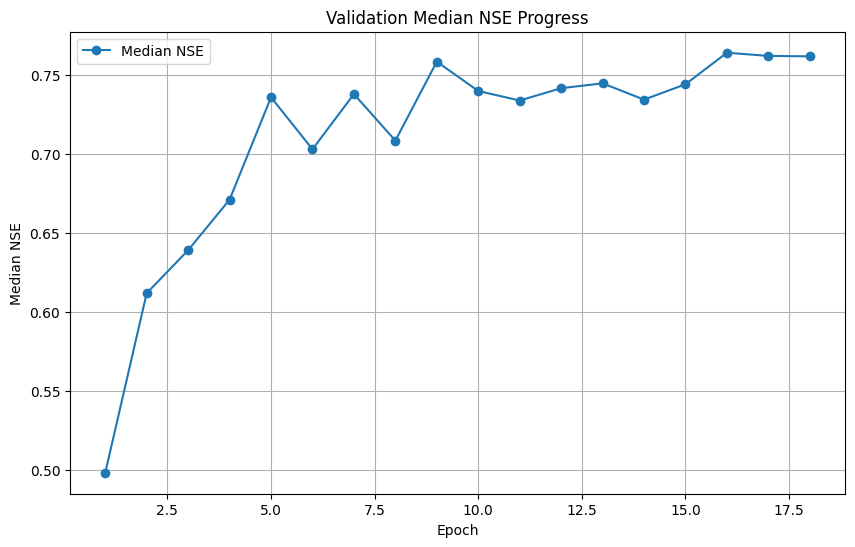

In [7]:
evaluator.plot_validation()

In [9]:
print(evaluator)

Summary Statistic: 
count    647.000000
mean      -4.027833
std       41.998053
min     -693.073063
25%        0.065748
50%        0.228331
75%        0.361127
max        0.684624
Name: NSE, dtype: float64

Summary Statistic: 
count    647.000000
mean      -0.065823
std        2.430488
min      -36.050702
25%        0.008171
50%        0.217447
75%        0.414099
max        0.756598
Name: KGE, dtype: float64

Performance Summary: 
Performance
Unsatisfactory    354
N/A               328
Good              163
Negative          130
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Periodically_plane_lstm_outliers_filtered_1703_100400 epoch 26


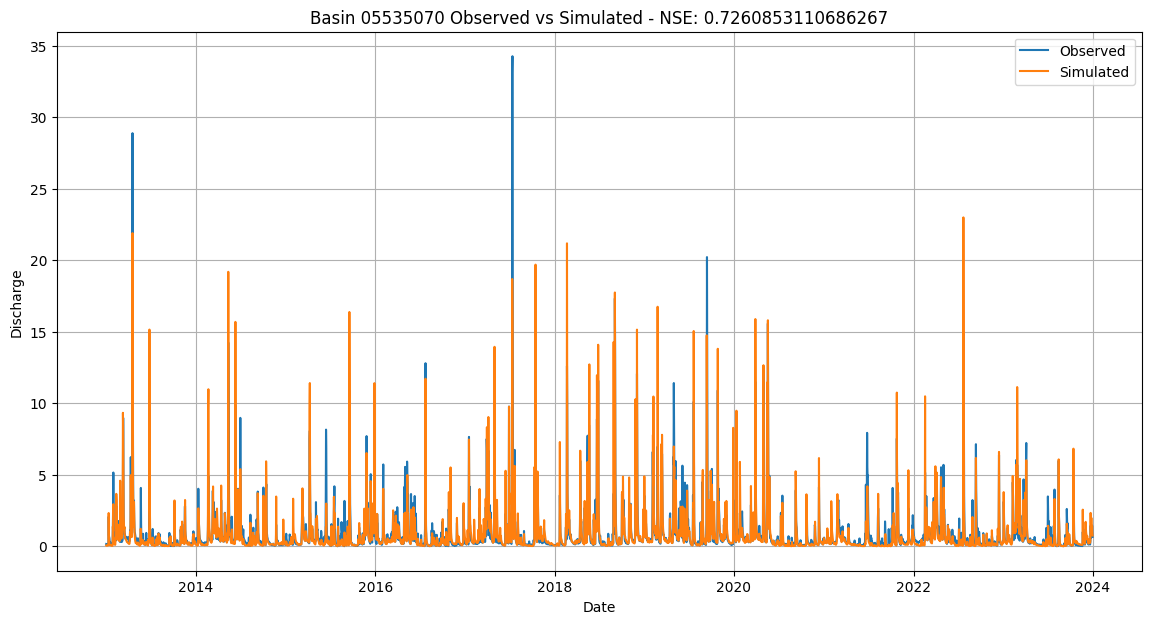

In [30]:
evaluator.plot_prediction("05535070")

## Plot the validation curve to possibly identify overfitting

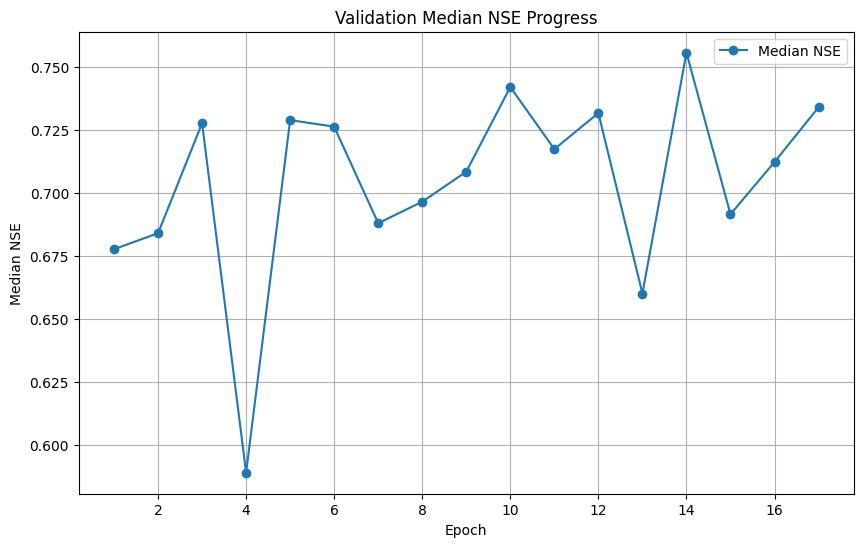

In [31]:
evaluator.plot_validation("Median")

## Evaluation Results

In [32]:
print(evaluator)

Summary Statistic: 
count    6.470000e+02
mean    -3.299132e+60
std      8.391736e+61
min     -2.134538e+63
25%      1.839860e-01
50%      5.036016e-01
75%      6.457838e-01
max      8.590568e-01
Name: NSE, dtype: float64

Performance Summary: 
Performance
Negative          455
Good              378
Unsatisfactory    102
Excellent          40
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Periodically_eslstm_1303_085231 epoch 17


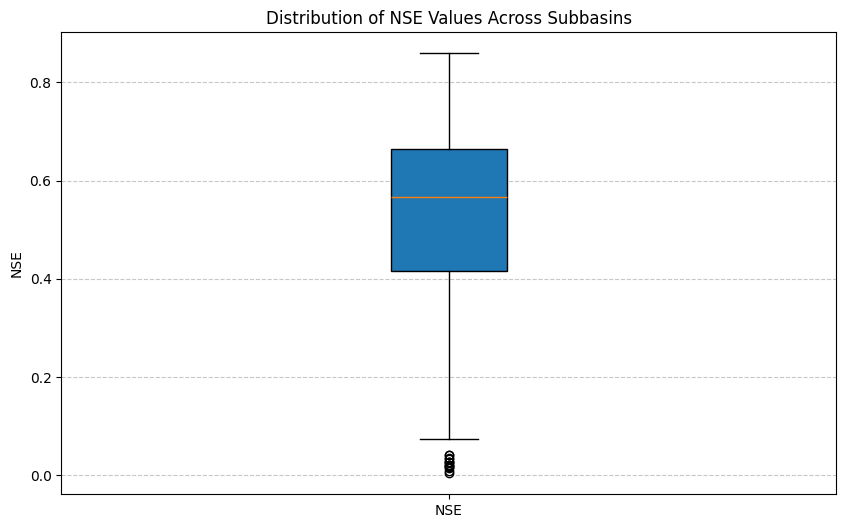

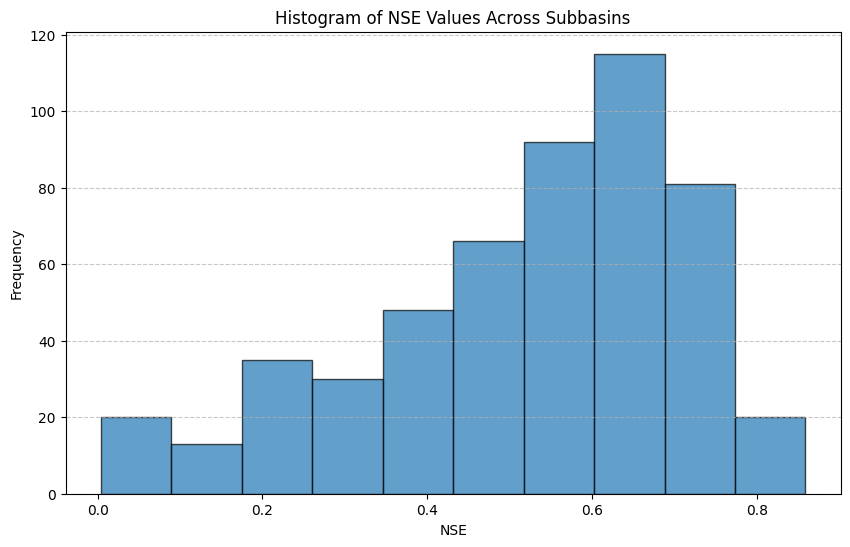

In [33]:
evaluator.plot_nse_distribution()

## Scatterplot of NSE vs Coverage

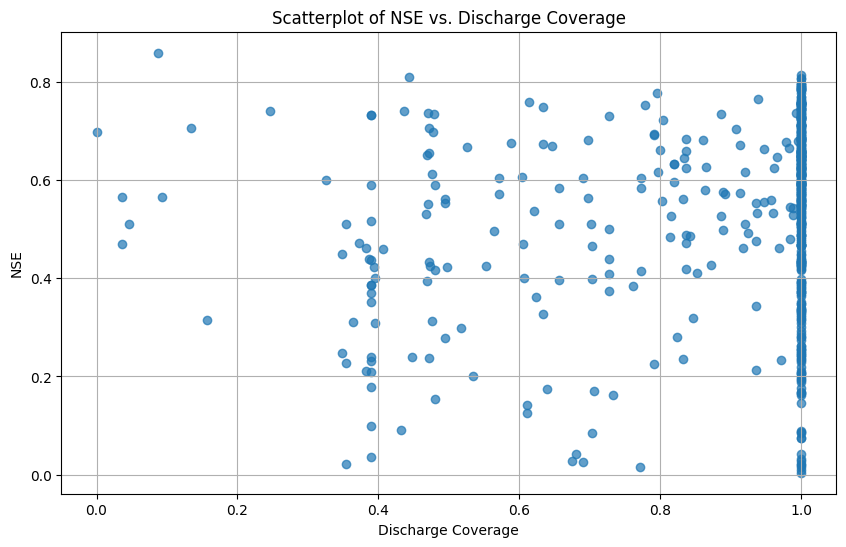

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

nse_df = evaluator.get_nse()
nse_df_filtered = nse_df[nse_df["NSE"] > 0]
coverage_df = pd.read_csv("metadata/coverage.csv")

# Merge the two dataframes on 'basin_id'
merged_df = pd.merge(nse_df_filtered, coverage_df, on="basin_id", how="inner")

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["discharge_coverage"], merged_df["NSE"], alpha=0.7)
plt.xlabel("Discharge Coverage")
plt.ylabel("NSE")
plt.title("Scatterplot of NSE vs. Discharge Coverage")
plt.grid(True)
plt.show()

In [35]:
nse_df_filtered.describe()

,NSE
count,520.000000
mean,0.522116
std,0.191528
min,0.003950
25%,0.415344
50%,0.565521
75%,0.663759
max,0.859057


In [36]:
nse_df.to_csv("result.csv")

## LBRM

In [1]:
from util.Evaluator import Evaluator

model_dir = "EA-LSTM_LowerLearningRate_0404_074727" # Specify the model name
epoch_num = 18 # Specify the epoch number
eval_dir = "metadata/LBRM_daymet" # Directory to the csv files for evaluation
eval_list = "basin_list/LBRM.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/1980",
                      test_end_date="31/12/2023",
                      mean=3.2232695112217513,
                      var=5.16634650602,
                      apply_transformation=True,)

100%|██████████| 94/94 [00:03<00:00, 26.98it/s]


In [2]:
print(evaluator)

Summary Statistic: 
count    92.000000
mean     -1.502138
std       3.380067
min     -25.956634
25%      -1.315034
50%      -0.561532
75%      -0.252976
max       0.011691
Name: NSE, dtype: float64

Summary Statistic: 
count    92.000000
mean     -0.887093
std       0.984982
min      -9.560673
25%      -0.835892
50%      -0.775811
75%      -0.734667
max      -0.278567
Name: KGE, dtype: float64

Performance Summary: 
Performance
Negative          90
Unsatisfactory     2
N/A                2
Name: count, dtype: int64

evaluate EA-LSTM_LowerLearningRate_0404_074727 epoch 18


In [3]:
evaluator.get_prediction("eri01")

(-0.6173083888252777,
 -0.6699818040452516,
 array([40.404465, 40.404503, 40.404526, ..., 31.95427 , 31.965675,
        31.860813], dtype=float32))

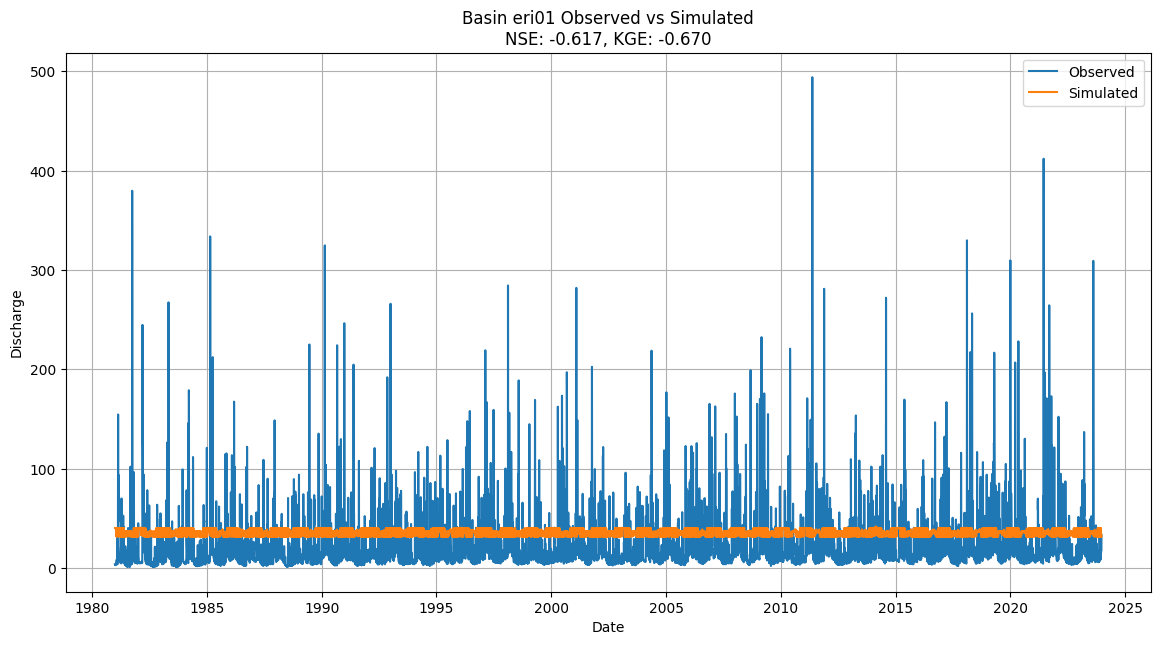

In [4]:
evaluator.plot_prediction("eri01")

In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

csv_dir = Path("metadata/LBRM_daymet")
csv_files = list(csv_dir.glob("*.csv"))

for csv_file in tqdm(csv_files, desc="Renaming 'Date' to 'date' in CSVs"):
    try:
        df = pd.read_csv(csv_file)
        if "Date" in df.columns:
            df.rename(columns={"Date": "date"}, inplace=True)
            df.to_csv(csv_file, index=False)
    except Exception as e:
        print(f"Error processing {csv_file.name}: {e}")

Renaming 'Date' to 'date' in CSVs: 100%|██████████| 121/121 [00:07<00:00, 16.84it/s]
